# Фаза 1: Эксперименты по улучшению RAG

Эксперименты по улучшению **ретривера** и **генератора**: подбор top-k, размера чанка, эмбеддера, фильтра по метаданным, two-stage извлечения с реранкером, гибридного retrieval, модели LLM и температуры генерации ответов.

8 этапов:

1. **Этап 1 - top-k × размер чанка:** сетка комбинаций `(top_k, chunk_size)`. Для каждого размера чанка (128, 256, 512) - свой датасет на HF и своя коллекция Qdrant.
2. **Этап 2 - модель-эмбеддер:** при выбранных top_k и chunk_size перебираются эмбеддеры. Для каждого - своя коллекция и переиндексация; датасет тот же с HF (под выбранный chunk_size).
3. **Этап 3 - фильтр по метаданным:** при выбранных top_k, chunk_size и эмбеддере - использование метаданных (название игры) при поиске: `retrieval.use_metadata_filter=true` vs `false`, фильтр по `game_titles` в Qdrant.
4. **Этап 4 - two-stage retrieval:** при тех же настройках - two-stage retrieval с реранкером (first_stage_k -> реранкер -> second_stage_k): `retrieval.two_stage=true` vs `false`.
5. **Этап 5 - подбор first_stage_k и second_stage_k:** при включённом two-stage - сетка по `first_stage_k` (100, 200, 300, 500) и `second_stage_k` (3, 5, 7, 10), выбор лучшей пары по метрикам ретривера.
6. **Этап 6 - гибридный retrieval:** сравнение dense baseline, RRF и weighted-гибрида при фиксированных лучших настройках из этапов 1-5.
7. **Этап 7 - подбор модели генератора (LLM):** при фиксированном выбранном ретривере перебор модели генерации; для каждой: ChrF++, ROUGE, semantic similarity, LLM-judge (faithfulness, relevance, correctness).
8. **Этап 8 - подбор температуры генерации:** при выбранной модели генератора перебор температуры (0.0–0.3). Для каждой температуры - 3 прогона для проверки устойчивости. Агрегация mean/std по метрикам пайплайна.

**Бейзлайн:** эмбеддер `intfloat/multilingual-e5-base`, коллекция под выбранный chunk size, генератор `qwen2.5:1.5b`.

**Датасеты:** загружаются с Hugging Face Hub (конфиг `data.eval_dataset_hf_repo`). Файлы: `boardgame_rules_qa_dataset_ru_chunk128.jsonl`, `boardgame_rules_qa_dataset_ru_chunk256.jsonl`, `boardgame_rules_qa_dataset_ru_chunk512.jsonl`. Коллекции Qdrant подготавливаются заранее (локально).

## Setup

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from omegaconf import OmegaConf
from src.config import BASE_DIR, get_cfg, paths_from_cfg
from src.eval import run_full_evaluation, run_retriever_evaluation
from src.indexer import index_documents

RESULTS_DIR = Path.cwd().parent / "results"
RESULTS_DIR.mkdir(exist_ok=True)
paths = paths_from_cfg(get_cfg())
EVAL_DATASETS_DIR = paths["eval_datasets_dir"]
EVAL_DATASET_HF_REPO = OmegaConf.select(get_cfg(), "data.eval_dataset_hf_repo", default=None) or ""
print("Results dir:", RESULTS_DIR.relative_to(BASE_DIR))
print("Eval datasets: HF repo =", EVAL_DATASET_HF_REPO or "(not set)")

Results dir: research/rag_experiments/results
Eval datasets: HF repo = LHLHLHE/boardgame_rules_qa_dataset_ru


## Подготовка: датасеты и коллекции для chunk-size 128, 256, 512

Для каждого размера чанка нужны: датасет `boardgame_rules_qa_dataset_ru_chunk{S}.jsonl` и коллекция Qdrant `boardgame_rules_chunk{S}`. Запустите один раз (из корня `research/rag_experiments`):

```bash
python scripts/prepare_chunk_datasets_and_collections.py
```

Или только датасеты: `--skip-index`; только индексация: `--skip-datasets`.

In [2]:
# Имена файлов датасетов на HF для этапа 1 (chunk 128, 256, 512)
for s in (128, 256, 512):
    fname = f"boardgame_rules_qa_dataset_ru_chunk{s}.jsonl"
    print(f"  {fname}: repo={EVAL_DATASET_HF_REPO or 'NOT SET'}")

  boardgame_rules_qa_dataset_ru_chunk128.jsonl: repo=LHLHLHE/boardgame_rules_qa_dataset_ru
  boardgame_rules_qa_dataset_ru_chunk256.jsonl: repo=LHLHLHE/boardgame_rules_qa_dataset_ru
  boardgame_rules_qa_dataset_ru_chunk512.jsonl: repo=LHLHLHE/boardgame_rules_qa_dataset_ru


## Этап 1 - сетка top-k × chunk size

In [3]:
TOPK_VALUES = [3, 5, 7, 10]
CHUNK_SIZES = [128, 256, 512]
TOPK_CHUNK_GRID = []
for top_k in TOPK_VALUES:
    for chunk_size in CHUNK_SIZES:
        TOPK_CHUNK_GRID.append({
            "id": f"topk{top_k}_chunk{chunk_size}",
            "overrides": [
                f"retrieval.top_k={top_k}",
                f"qdrant.collection_name=boardgame_rules_chunk{chunk_size}",
            ],
            "dataset_hf_filename": f"boardgame_rules_qa_dataset_ru_chunk{chunk_size}.jsonl",
            "top_k": top_k,
            "chunk_size": chunk_size,
        })
print(f"Этап 1 (top-k × chunk size): {len(TOPK_CHUNK_GRID)} экспериментов")

Этап 1 (top-k × chunk size): 12 экспериментов


In [4]:
RUN_STAGE1 = True
LIMIT = None
SKIP_IF_EXISTS = True

phase1_results = []
for item in TOPK_CHUNK_GRID:
    exp_id = item["id"]
    overrides = item["overrides"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if RUN_STAGE1:
        if SKIP_IF_EXISTS and out_path.exists():
            print(f"Skip (exists): {exp_id}")
            with open(out_path, encoding="utf-8") as f:
                phase1_results.append(json.load(f))
            continue
        if not EVAL_DATASET_HF_REPO:
            print("Skip: EVAL_DATASET_HF_REPO not set")
            break
        print(f"Running: {exp_id} top_k={item['top_k']} chunk_size={item['chunk_size']}")
        cfg = get_cfg(overrides)
        result = run_retriever_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
        )
        result["experiment_id"] = exp_id
        result["top_k"] = item["top_k"]
        result["chunk_size"] = item["chunk_size"]
        result["embedding_model"] = result["models"]["embedding"]
        to_save = {
            "experiment_id": exp_id,
            "top_k": result["top_k"],
            "chunk_size": result["chunk_size"],
            "embedding_model": result["embedding_model"],
            "models": result["models"],
            "retriever": result["retriever"],
            "n_samples": result["n_samples"],
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        phase1_results.append(result)
    else:
        if out_path.exists():
            with open(out_path, encoding="utf-8") as f:
                phase1_results.append(json.load(f))
        else:
            print(f"Missing: {exp_id}")

print(f"Этап 1: {len(phase1_results)} результатов")

Skip (exists): topk3_chunk128
Skip (exists): topk3_chunk256
Skip (exists): topk3_chunk512
Skip (exists): topk5_chunk128
Skip (exists): topk5_chunk256
Skip (exists): topk5_chunk512
Skip (exists): topk7_chunk128
Skip (exists): topk7_chunk256
Skip (exists): topk7_chunk512
Skip (exists): topk10_chunk128
Skip (exists): topk10_chunk256
Skip (exists): topk10_chunk512
Этап 1: 12 результатов


In [5]:
rows = []
for r in phase1_results:
    row = {
        "experiment_id": r.get("experiment_id", ""),
        "top_k": r.get("top_k"),
        "chunk_size": r.get("chunk_size"),
        "embedding_model": r.get("embedding_model", r.get("models", {}).get("embedding", "")),
    }
    for k, v in r.get("retriever", {}).items():
        if k != "precision_at_k":
            row[k] = v
    rows.append(row)

phase1_df = pd.DataFrame(rows)

In [6]:
phase1_pivot = phase1_df.set_index(["chunk_size", "top_k"])
phase1_pivot

,,experiment_id,embedding_model,recall_at_k,map_at_k,ndcg_at_k,hit_rate
chunk_size,top_k,,,,,,
128,3,topk3_chunk128,intfloat/multilingual-e5-base,0.687500,0.589306,0.638267,0.815
256,3,topk3_chunk256,intfloat/multilingual-e5-base,0.663333,0.572778,0.617318,0.765
512,3,topk3_chunk512,intfloat/multilingual-e5-base,0.595000,0.504722,0.541591,0.665
128,5,topk5_chunk128,intfloat/multilingual-e5-base,0.746667,0.607597,0.667236,0.875
256,5,topk5_chunk256,intfloat/multilingual-e5-base,0.749167,0.600069,0.656322,0.825
512,5,topk5_chunk512,intfloat/multilingual-e5-base,0.693333,0.533222,0.585582,0.750
128,7,topk7_chunk128,intfloat/multilingual-e5-base,0.786667,0.616149,0.682950,0.905
256,7,topk7_chunk256,intfloat/multilingual-e5-base,0.797500,0.609673,0.675405,0.875
512,7,topk7_chunk512,intfloat/multilingual-e5-base,0.785833,0.550603,0.619984,0.835


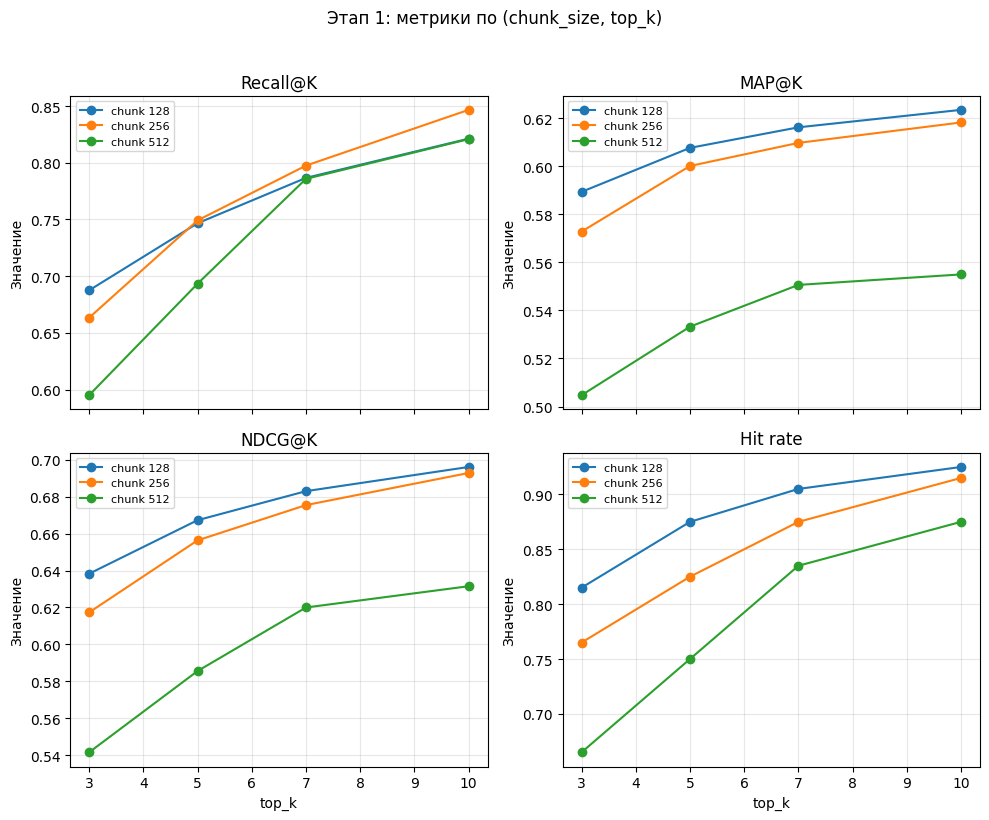

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()
metrics = ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
metric_titles = {
    "recall_at_k": "Recall@K",
    "map_at_k": "MAP@K",
    "ndcg_at_k": "NDCG@K",
    "hit_rate": "Hit rate",
}
chunk_sizes = sorted(phase1_df["chunk_size"].unique())
for idx, m in enumerate(metrics):
    ax = axes[idx]
    for chunk_size in chunk_sizes:
        sub = phase1_df[phase1_df["chunk_size"] == chunk_size].sort_values("top_k")
        if m not in sub.columns:
            continue
        x = sub["top_k"].astype(int)
        ax.plot(x, sub[m], marker="o", label=f"chunk {chunk_size}")
    ax.set_title(metric_titles.get(m, m))
    ax.set_ylabel("Значение")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[2].set_xlabel("top_k")
axes[3].set_xlabel("top_k")
plt.suptitle("Этап 1: метрики по (chunk_size, top_k)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

- **Главный критерий выбора**: качество ранжирования (**NDCG@K** и **MAP@K**), т.к. в генерацию реально попадают только top-K чанков; важно, чтобы релевантные были как можно выше в выдаче.
- **Наблюдение по результатам**: `chunk_size=128` даёт лучшую картину по **MAP@K**, **NDCG@K** и **Hit rate**.
- **Recall@K** местами выше у `chunk_size=256`, но при текущем датасете (максимум 3 gold-чанка на пример) recall быстро выходит на плато при росте K, поэтому при сравнении эту метрику используем как дополнительную проверку, а не как основную цель.

**Лучший набор параметров для следующих этапов:**

- **`BEST_CHUNK_SIZE = 128`**
- **`BEST_TOP_K = 10`**

## Этап 2 - эмбеддеры

In [8]:
# Выбор лучшей пары из этапа 1
BEST_TOP_K = 10
BEST_CHUNK_SIZE = 128
CHUNK_OVERLAP = {128: 20, 256: 40, 512: 80}.get(BEST_CHUNK_SIZE, 80)
BEST_DATASET_HF_FILENAME = f"boardgame_rules_qa_dataset_ru_chunk{BEST_CHUNK_SIZE}.jsonl"

# Сетка эмбеддеров
EMBEDDER_GRID = [
    {
        "id": f"embed_e5_chunk{BEST_CHUNK_SIZE}",
        "overrides": [
            f"retrieval.top_k={BEST_TOP_K}",
            f"qdrant.collection_name=boardgame_rules_chunk{BEST_CHUNK_SIZE}",
        ],
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        "top_k": BEST_TOP_K,
        "chunk_size": BEST_CHUNK_SIZE,
        "run_index_first": False,
    },
    {
        "id": f"embed_rosberta_chunk{BEST_CHUNK_SIZE}",
        "overrides": [
            f"retrieval.top_k={BEST_TOP_K}",
            f"chunking.chunk_size={BEST_CHUNK_SIZE}",
            f"chunking.chunk_overlap={CHUNK_OVERLAP}",
            "embedding.model=ai-forever/ru-en-RoSBERTa",
            "embedding.dim=1024",
            f"qdrant.collection_name=boardgame_rules_chunk{BEST_CHUNK_SIZE}_rosberta",
        ],
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        "top_k": BEST_TOP_K,
        "chunk_size": BEST_CHUNK_SIZE,
        "run_index_first": False,
    },
    {
        "id": f"embed_mpnet_chunk{BEST_CHUNK_SIZE}",
        "overrides": [
            f"retrieval.top_k={BEST_TOP_K}",
            f"chunking.chunk_size={BEST_CHUNK_SIZE}",
            f"chunking.chunk_overlap={CHUNK_OVERLAP}",
            "embedding.model=sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
            "embedding.dim=768",
            "embedding.text_instruction=\"\"",
            "embedding.query_instruction=\"\"",
            f"qdrant.collection_name=boardgame_rules_chunk{BEST_CHUNK_SIZE}_mpnet",
        ],
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        "top_k": BEST_TOP_K,
        "chunk_size": BEST_CHUNK_SIZE,
        "run_index_first": False,
    },
    {
        "id": f"embed_gte_chunk{BEST_CHUNK_SIZE}",
        "overrides": [
            f"retrieval.top_k={BEST_TOP_K}",
            f"chunking.chunk_size={BEST_CHUNK_SIZE}",
            f"chunking.chunk_overlap={CHUNK_OVERLAP}",
            "embedding.model=Alibaba-NLP/gte-multilingual-base",
            "embedding.dim=768",
            "embedding.text_instruction=\"\"",
            "embedding.query_instruction=\"\"",
            f"qdrant.collection_name=boardgame_rules_chunk{BEST_CHUNK_SIZE}_gte",
        ],
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        "top_k": BEST_TOP_K,
        "chunk_size": BEST_CHUNK_SIZE,
        "run_index_first": False,
    },
]
print(f"Этап 2: {len(EMBEDDER_GRID)} экспериментов (эмбеддеры, top_k={BEST_TOP_K}, chunk_size={BEST_CHUNK_SIZE})")

Этап 2: 4 экспериментов (эмбеддеры, top_k=10, chunk_size=128)


In [9]:
RUN_STAGE2 = True
phase2_results = []
for item in EMBEDDER_GRID:
    exp_id = item["id"]
    overrides = item["overrides"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if RUN_STAGE2:
        if SKIP_IF_EXISTS and out_path.exists():
            print(f"Skip (exists): {exp_id}")
            with open(out_path, encoding="utf-8") as f:
                phase2_results.append(json.load(f))
            continue
        if not EVAL_DATASET_HF_REPO:
            print("Skip: EVAL_DATASET_HF_REPO not set")
            break
        print(f"Running: {exp_id}")
        cfg = get_cfg(overrides)
        if item.get("run_index_first"):
            index_documents(cfg, recreate_collection=True, batch_size=200)
        result = run_retriever_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
        )
        result["experiment_id"] = exp_id
        result["top_k"] = item["top_k"]
        result["chunk_size"] = item["chunk_size"]
        result["embedding_model"] = result["models"]["embedding"]
        to_save = {
            "experiment_id": exp_id,
            "top_k": result["top_k"],
            "chunk_size": result["chunk_size"],
            "embedding_model": result["embedding_model"],
            "models": result["models"],
            "retriever": result["retriever"],
            "n_samples": result["n_samples"],
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        phase2_results.append(result)
    else:
        if out_path.exists():
            with open(out_path, encoding="utf-8") as f:
                phase2_results.append(json.load(f))
        else:
            print(f"Missing: {exp_id}")
print(f"Этап 2: {len(phase2_results)} результатов")

Skip (exists): embed_e5_chunk128
Skip (exists): embed_rosberta_chunk128
Skip (exists): embed_mpnet_chunk128
Skip (exists): embed_gte_chunk128
Этап 2: 4 результатов


In [10]:
rows = []
for r in phase2_results:
    row = {
        "experiment_id": r.get("experiment_id", ""),
        "top_k": r.get("top_k"),
        "chunk_size": r.get("chunk_size"),
        "embedding_model": r.get("embedding_model", r.get("models", {}).get("embedding", "")),
    }
    for k, v in r.get("retriever", {}).items():
        if k != "precision_at_k":
            row[k] = v
    rows.append(row)
phase2_df = pd.DataFrame(rows)
display_cols = ["experiment_id", "embedding_model", "top_k", "chunk_size"] + ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
display_cols = [c for c in display_cols if c in phase2_df.columns]

In [11]:
phase2_pivot = phase2_df.set_index(["embedding_model"])
phase2_pivot

,experiment_id,top_k,chunk_size,recall_at_k,map_at_k,ndcg_at_k,hit_rate
embedding_model,,,,,,,
intfloat/multilingual-e5-base,embed_e5_chunk128,10,128,0.821250,0.623409,0.696042,0.925
ai-forever/ru-en-RoSBERTa,embed_rosberta_chunk128,10,128,0.747500,0.522077,0.595737,0.845
sentence-transformers/paraphrase-multilingual-mpnet-base-v2,embed_mpnet_chunk128,10,128,0.452500,0.310250,0.358862,0.535
Alibaba-NLP/gte-multilingual-base,embed_gte_chunk128,10,128,0.721667,0.460359,0.544727,0.835


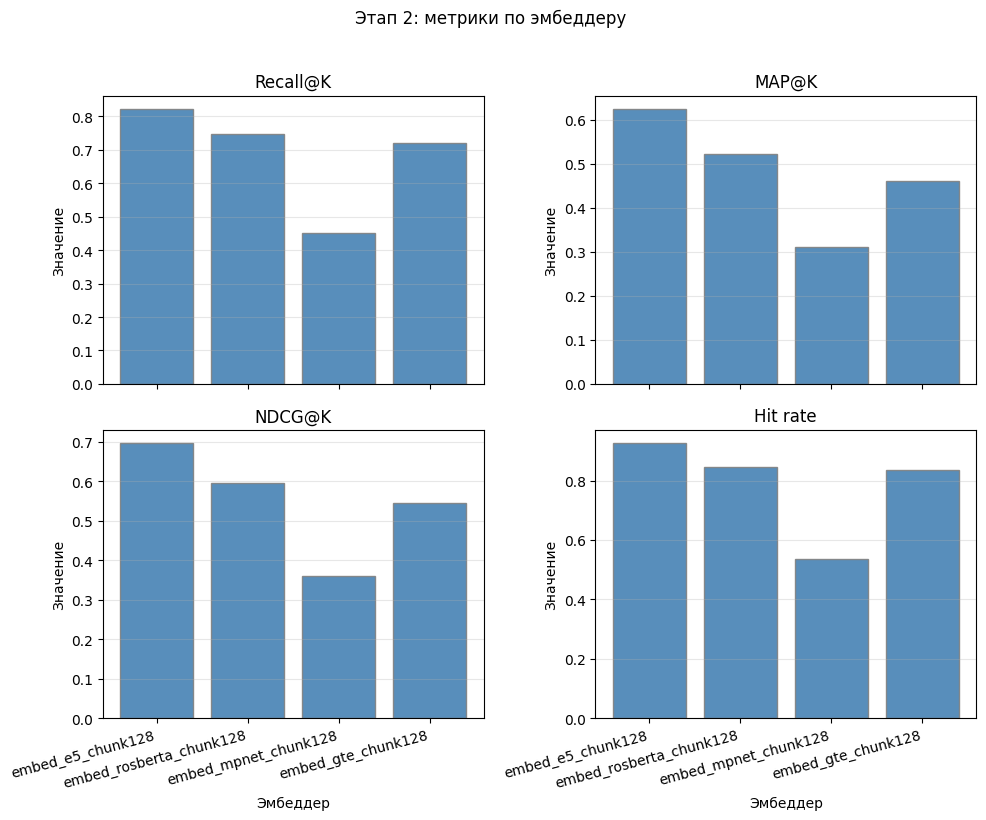

In [12]:
if len(phase2_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    axes = axes.flatten()
    metrics = ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
    metric_titles = {
        "recall_at_k": "Recall@K",
        "map_at_k": "MAP@K",
        "ndcg_at_k": "NDCG@K",
        "hit_rate": "Hit rate",
    }
    x_pos = range(len(phase2_df))
    labels = phase2_df["experiment_id"].tolist()
    for idx, m in enumerate(metrics):
        ax = axes[idx]
        if m in phase2_df.columns:
            ax.bar(x_pos, phase2_df[m], color="steelblue", edgecolor="gray", alpha=0.9)
        ax.set_title(metric_titles.get(m, m))
        ax.set_ylabel("Значение")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, rotation=15, ha="right")
        ax.grid(True, alpha=0.3, axis="y")
    axes[2].set_xlabel("Эмбеддер")
    axes[3].set_xlabel("Эмбеддер")
    plt.suptitle("Этап 2: метрики по эмбеддеру", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- **Что сравнивали**: несколько эмбеддеров (отдельные коллекции Qdrant) при фиксированных **`BEST_CHUNK_SIZE=128`** и **`BEST_TOP_K=10`**.
- **Как оценивали**: только ретривер‑метрики (`recall@k`, `map@k`, `ndcg@k`, `hit_rate`).
- **Наблюдение**:
  - важнее всего качество **ранжирования верхней выдачи** (MAP/NDCG) - именно эти фрагменты чаще всего попадут в контекст;
  - альтернативные эмбеддеры могут давать точечные улучшения, но если выигрыш неустойчив/не системный, цена переиндексации не оправдывается.
- **Выбор**: оставить базовый эмбеддер **`intfloat/multilingual-e5-base`** (т.е. **`BEST_EMBEDDER_OVERRIDES = []`**, коллекция `boardgame_rules_chunk128`).
- **Почему**: по итогам сравнения это лучший/наиболее стабильный вариант на ключевых метриках ретривера в текущей постановке.


## Этап 3 - фильтр по метаданным

In [13]:
def run_or_load_phase3_grid(grid):
    results = []
    for item in grid:
        exp_id = item["id"]
        out_path = RESULTS_DIR / f"{exp_id}.json"

        # load existing
        if SKIP_IF_EXISTS and out_path.exists():
            with open(out_path, encoding="utf-8") as f:
                results.append(json.load(f))
            continue

        # run missing
        if not EVAL_DATASET_HF_REPO:
            print("Skip: EVAL_DATASET_HF_REPO not set")
            break
        cfg = get_cfg(item["overrides"])
        result = run_retriever_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
        )
        result["experiment_id"] = exp_id
        result["use_metadata_filter"] = item.get("use_metadata_filter", False)
        result["two_stage"] = item.get("two_stage", False)
        to_save = {
            "experiment_id": exp_id,
            "use_metadata_filter": result["use_metadata_filter"],
            "two_stage": result["two_stage"],
            "models": result["models"],
            "retriever": result["retriever"],
            "n_samples": result["n_samples"],
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        results.append(result)

    return results

In [14]:
# Сетки этапа 3 (используем лучшие top_k, chunk_size и выбранный эмбеддер из этапа 2)
# Явно задаём выбранную модель: коллекция + overrides для embedding
BEST_EMBEDDER_COLLECTION = f"boardgame_rules_chunk{BEST_CHUNK_SIZE}"
# Для e5 (дефолт) - пусто
BEST_EMBEDDER_OVERRIDES = []

def stage3_overrides(extra):
    return (
        ["llm.model=qwen2.5:1.5b", f"retrieval.top_k={BEST_TOP_K}"]
        + BEST_EMBEDDER_OVERRIDES
        + [f"qdrant.collection_name={BEST_EMBEDDER_COLLECTION}"]
        + extra
    )

def without_llm_model_override(overrides: list[str]) -> list[str]:
    return [o for o in overrides if not (isinstance(o, str) and o.startswith("llm.model="))]

METADATA_GRID = [
    {
        "id": "meta_off",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=false"]),
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        "use_metadata_filter": False,
        "two_stage": False
    },
    {
        "id": "meta_on",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=true"]),
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        "use_metadata_filter": True,
        "two_stage": False
    },
]
print(f"Этап 3 (метаданные): {len(METADATA_GRID)} экспериментов")

Этап 3 (метаданные): 2 экспериментов


In [15]:
phase3_results = []
phase3_results.extend(run_or_load_phase3_grid(METADATA_GRID))

In [16]:
phase3_df = pd.DataFrame([
    {
        "experiment_id": r.get("experiment_id"),
        "use_metadata_filter": r.get("use_metadata_filter"),
        "two_stage": r.get("two_stage"),
        **{k: v for k, v in r.get("retriever", {}).items()},
    }
    for r in phase3_results
])

In [17]:
phase3_pivot = phase3_df.set_index("experiment_id")
phase3_pivot

,use_metadata_filter,two_stage,recall_at_k,precision_at_k,map_at_k,ndcg_at_k,hit_rate
experiment_id,,,,,,,
meta_off,False,False,0.821250,0.111,0.623409,0.696042,0.925
meta_on,True,False,0.862917,0.118,0.657297,0.730182,0.950


- **Что сравнивали**: `retrieval.use_metadata_filter=false` vs `true` при фиксированных `chunk_size/top_k` и выбранном эмбеддере.
- **Ключевое условие корректности**: фильтр работает только если в запросе есть **нормализованное `game_title`** (или список), и в Qdrant‑payload у чанков сохранено то же нормализованное значение.
- **Наблюдение**: включение фильтра обычно повышает «попадание в нужную игру» - это видно по росту **`hit_rate`/`recall_at_k`** и улучшению ранжирования (MAP/NDCG), потому что мы убираем «чужие» игры из пространства поиска.
- **Риск**: если `game_title` отсутствует или не совпадает (опечатки/варианты написания), жёсткий фильтр может **уронить recall**.
- **Выбор**: **`BEST_USE_METADATA = True`**.
- **Как использовать безопасно**:
  - если `game_title` не задан/пустой - автоматически **отключать фильтр** (fallback на обычный поиск);
  - держать нормализацию названий (и при записи метаданных, и при формировании запроса).


## Этап 4 - two-stage

In [18]:
TWO_STAGE_GRID = [
    {
        "id": "twostage_off",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=true", "retrieval.two_stage=false"]),
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        "use_metadata_filter": True,
        "two_stage": False
    },
    {
        "id": "twostage_on",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=true", "retrieval.two_stage=true", "retrieval.first_stage_k=100", "retrieval.second_stage_k=10"]),
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        "use_metadata_filter": True,
        "two_stage": True
    },
    {
        "id": "twostage_on_without_meta",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=false", "retrieval.two_stage=true", "retrieval.first_stage_k=100", "retrieval.second_stage_k=10"]),
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        "use_metadata_filter": False,
        "two_stage": True
    },
]
print(f"Этап 4 (two-stage): {len(TWO_STAGE_GRID)} экспериментов")

Этап 4 (two-stage): 3 экспериментов


In [19]:
phase4_results = []
phase4_results.extend(run_or_load_phase3_grid(TWO_STAGE_GRID))

In [20]:
phase4_df = pd.DataFrame([
    {
        "experiment_id": r.get("experiment_id"),
        "use_metadata_filter": r.get("use_metadata_filter"),
        "two_stage": r.get("two_stage"),
        **{k: v for k, v in r.get("retriever", {}).items()},
    }
    for r in phase4_results
])

In [21]:
phase4_pivot = phase4_df.set_index("experiment_id")
phase4_pivot

,use_metadata_filter,two_stage,recall_at_k,precision_at_k,map_at_k,ndcg_at_k,hit_rate
experiment_id,,,,,,,
twostage_off,True,False,0.862917,0.1180,0.657297,0.730182,0.950
twostage_on,True,True,0.870417,0.1190,0.658297,0.732514,0.955
twostage_on_without_meta,False,True,0.823750,0.1115,0.623909,0.696929,0.925


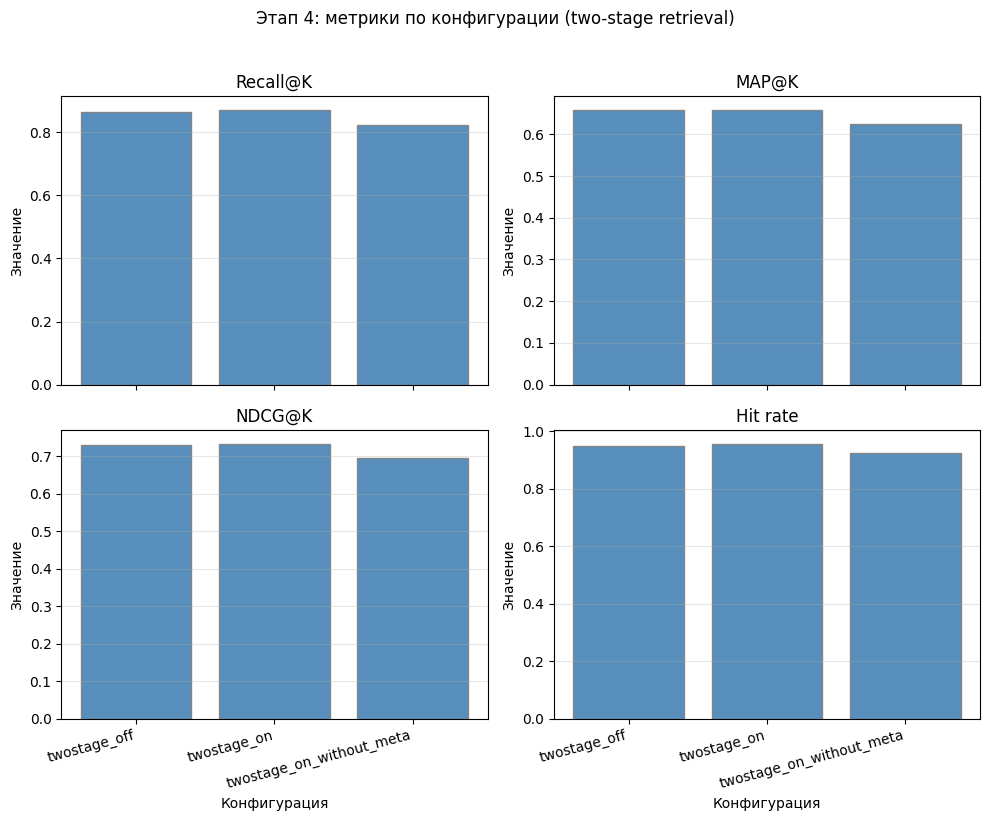

In [22]:
if len(phase4_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    axes = axes.flatten()
    metrics = ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
    metric_titles = {
        "recall_at_k": "Recall@K",
        "map_at_k": "MAP@K",
        "ndcg_at_k": "NDCG@K",
        "hit_rate": "Hit rate",
    }
    x_pos = range(len(phase4_df))
    labels = phase4_df["experiment_id"].tolist()
    for idx, m in enumerate(metrics):
        ax = axes[idx]
        if m in phase4_df.columns:
            ax.bar(x_pos, phase4_df[m], color="steelblue", edgecolor="gray", alpha=0.9)
        ax.set_title(metric_titles.get(m, m))
        ax.set_ylabel("Значение")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, rotation=15, ha="right")
        ax.grid(True, alpha=0.3, axis="y")
    axes[2].set_xlabel("Конфигурация")
    axes[3].set_xlabel("Конфигурация")
    plt.suptitle("Этап 4: метрики по конфигурации (two-stage retrieval)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- **Что сравнивали**: конфигурации `retrieval.two_stage=false` vs `true` (в т.ч. варианты с/без метаданных), при фиксированных `chunk_size/top_k` и выбранном эмбеддере.
- **Почему это важно**: обычный dense‑retrieval часто приносит «почти релевантные» фрагменты; реранкер помогает **переупорядочить** кандидатов так, чтобы в верх выдачи попадали наиболее точные куски.
- **На что смотрим**: для ретривера особенно показательны **`map_at_k`** и **`ndcg_at_k`** (качество ранжирования top‑K), а также **`hit_rate`/`recall_at_k`**.
- **Наблюдение**: при исходных параметрах two-stage даёт лишь небольшой прирост retrieval-метрик.
- **Промежуточный вывод**: перед финальным решением нужно проверить чувствительность к `first_stage_k`/`second_stage_k` и устойчивость выигрыша.

## Этап 5 - подбор first_stage_k и second_stage_k

In [23]:
FIRST_STAGE_K_VALUES = [100, 200, 300, 500]
SECOND_STAGE_K_VALUES = [3, 5, 7, 10]
STAGE5_GRID = []
for fst in FIRST_STAGE_K_VALUES:
    for snd in SECOND_STAGE_K_VALUES:
        if snd > fst:
            continue
        exp_id = f"twostage_f{fst}_s{snd}"
        STAGE5_GRID.append({
            "id": exp_id,
            "overrides": stage3_overrides([
                "retrieval.use_metadata_filter=true",
                "retrieval.two_stage=true",
                f"retrieval.first_stage_k={fst}",
                f"retrieval.second_stage_k={snd}",
            ]),
            "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
            "use_metadata_filter": True,
            "two_stage": True,
            "first_stage_k": fst,
            "second_stage_k": snd,
        })
print(f"Этап 5: {len(STAGE5_GRID)} экспериментов (first_stage_k × second_stage_k)")

Этап 5: 16 экспериментов (first_stage_k × second_stage_k)


In [24]:
phase5_results = []
for item in STAGE5_GRID:
    exp_id = item["id"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if SKIP_IF_EXISTS and out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase5_results.append(json.load(f))
        continue
    if EVAL_DATASET_HF_REPO:
        cfg = get_cfg(item["overrides"])
        result = run_retriever_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
        )
        result["experiment_id"] = exp_id
        result["first_stage_k"] = item["first_stage_k"]
        result["second_stage_k"] = item["second_stage_k"]
        to_save = {
            "experiment_id": exp_id,
            "first_stage_k": item["first_stage_k"],
            "second_stage_k": item["second_stage_k"],
            "models": result["models"],
            "retriever": result["retriever"],
            "n_samples": result["n_samples"],
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        phase5_results.append(result)
    elif out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase5_results.append(json.load(f))

print(f"Этап 5: {len(phase5_results)} результатов")

Этап 5: 16 результатов


In [25]:
phase5_df = pd.DataFrame([
    {
        "experiment_id": r.get("experiment_id"),
        "first_stage_k": r.get("first_stage_k"),
        "second_stage_k": r.get("second_stage_k"),
        **{k: v for k, v in r.get("retriever", {}).items()},
    }
    for r in phase5_results
])

In [26]:
phase5_pivot = phase5_df.set_index(["first_stage_k", "second_stage_k"])
phase5_pivot

experiment_id  recall_at_k  precision_at_k  \
first_stage_k second_stage_k                                                   
100           3                twostage_f100_s3     0.710833        0.296667   
              5                twostage_f100_s5     0.772500        0.205000   
              7                twostage_f100_s7     0.824167        0.157857   
              10              twostage_f100_s10     0.870417        0.119000   
200           3                twostage_f200_s3     0.710833        0.296667   
              5                twostage_f200_s5     0.772500        0.205000   
              7                twostage_f200_s7     0.824167        0.157857   
              10              twostage_f200_s10     0.870417        0.119000   
300           3                twostage_f300_s3     0.710833        0.296667   
              5                twostage_f300_s5     0.772500        0.205000   
              7                twostage_f300_s7     0.824167        0.157857   
              10              twostage_f300_s10     0.870417        0.119000   
500           3                twostage_f500_s3     0.710833        0.296667   
              5                twostage_f500_s5     0.772500        0.205000   
              7                twostage_f500_s7     0.824167        0.157857   
              10              twostage_f500_s10     0.870417        0.119000   

                              map_at_k  ndcg_at_k  hit_rate  
first_stage_k second_stage_k                                 
100           3               0.618611   0.665311     0.835  
              5               0.638861   0.696189     0.890  
              7               0.649734   0.716117     0.930  
              10              0.658297   0.732514     0.955  
200           3               0.618611   0.665311     0.835  
              5               0.638861   0.696189     0.890  
              7               0.649734   0.716117     0.930  
              10              0.658297   0.732514     0.955  
300           3               0.618611   0.665311     0.835  
              5               0.638861   0.696189     0.890  
              7               0.649734   0.716117     0.930  
              10              0.658297   0.732514     0.955  
500           3               0.618611   0.665311     0.835  
              5               0.638861   0.696189     0.890  
              7               0.649734   0.716117     0.930  
              10              0.658297   0.732514     0.955

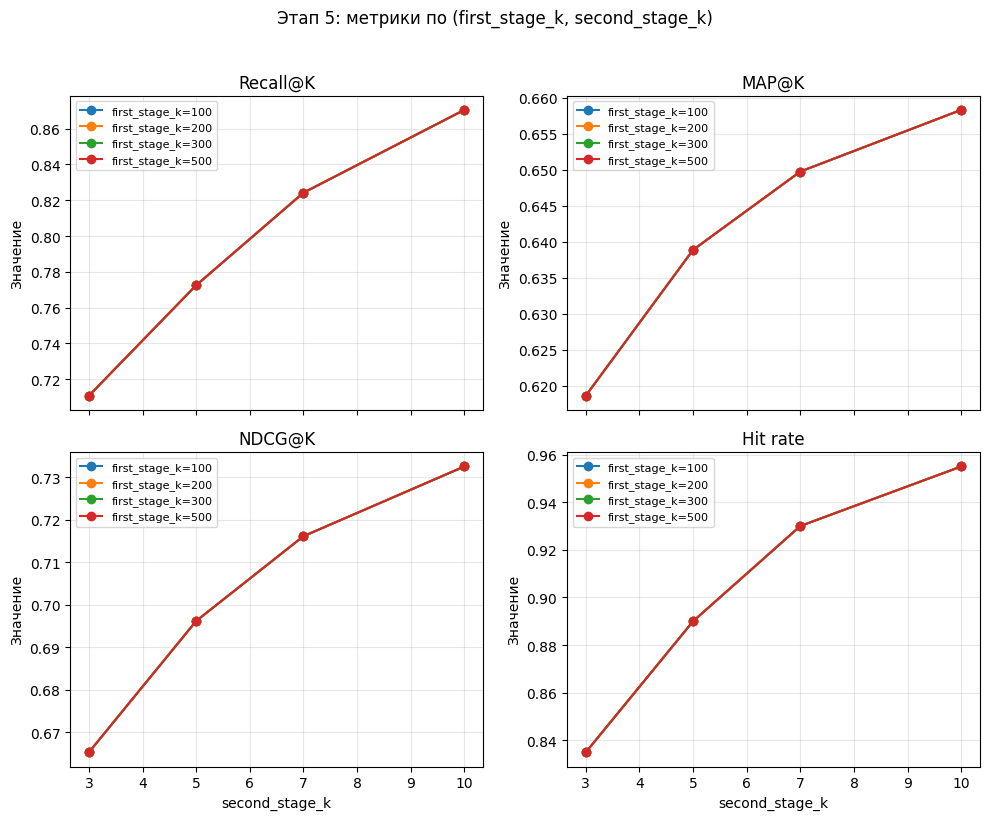

In [27]:
if len(phase5_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    axes = axes.flatten()
    metrics = ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
    metric_titles = {
        "recall_at_k": "Recall@K",
        "map_at_k": "MAP@K",
        "ndcg_at_k": "NDCG@K",
        "hit_rate": "Hit rate",
    }
    first_stage_values = sorted(phase5_df["first_stage_k"].unique())
    for idx, m in enumerate(metrics):
        ax = axes[idx]
        for fst in first_stage_values:
            sub = phase5_df[phase5_df["first_stage_k"] == fst].sort_values("second_stage_k")
            if m not in sub.columns or sub.empty:
                continue
            x = sub["second_stage_k"].astype(int)
            ax.plot(x, sub[m], marker="o", label=f"first_stage_k={fst}")
        ax.set_title(metric_titles.get(m, m))
        ax.set_ylabel("Значение")
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[2].set_xlabel("second_stage_k")
    axes[3].set_xlabel("second_stage_k")
    plt.suptitle("Этап 5: метрики по (first_stage_k, second_stage_k)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- **Что сравнивали**: сетку значений `first_stage_k ∈ {100, 200, 300, 500}` и `second_stage_k ∈ {3, 5, 7, 10}` при включённом two‑stage и включённых метаданных.
- **Интуиция**:
  - `first_stage_k` отвечает за «достать кандидатов побольше» (чтобы реранкеру было из чего выбирать).
  - `second_stage_k` - сколько документов реально уходит в контекст (слишком маленькое значение режет Recall, слишком большое размывает top‑N и увеличивает шум).
- **Наблюдение**: в текущем прогоне `first_stage_k ∈ {100, 200, 300, 500}` почти не влияет на метрики: для одинакового `second_stage_k` результаты совпадают. Основное изменение качества идёт от `second_stage_k` - чем больше документов после реранкинга попадает в контекст, тем выше recall/ranking‑метрики.
- **Итог по two-stage**: даже при лучшем варианте first_stage_k=100, second_stage_k=10 прирост минимальный.
- **Решение**: **не использовать two-stage в финальной конфигурации** (`BEST_TWO_STAGE = False`), чтобы не усложнять и не удорожать пайплайн без значимого выигрыша в качестве.

## Этап 6 - гибридный retrieval (RRF / weighted)

На этом этапе фиксируем лучшие настройки из этапов 1-5 и сравниваем варианты retrieval:
- гибрид RRF (несколько `k`),
- гибрид weighted (`k × alpha`).

In [28]:
BEST_USE_METADATA = True
BEST_TWO_STAGE = False
BEST_FIRST_STAGE_K = 100
BEST_SECOND_STAGE_K = 10

BEST_RETRIEVAL = {
    "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
    "chunk_size": BEST_CHUNK_SIZE,
    "top_k": BEST_TOP_K,
    "collection_name": BEST_EMBEDDER_COLLECTION,
    "embedding_model": "intfloat/multilingual-e5-base",
    "text_instruction": "passage: ",
    "query_instruction": "query: ",
    "use_metadata_filter": BEST_USE_METADATA,
    "two_stage": BEST_TWO_STAGE,
}

HYBRID_RRF_CANDS = [10, 20, 50]
HYBRID_WEIGHTED_POOLS = [10, 20, 50]
HYBRID_WEIGHTED_ALPHAS = [0.3, 0.5, 0.7]

STAGE6_RETRIEVER_EXTRAS = [
    f"retrieval.use_metadata_filter={'true' if BEST_RETRIEVAL['use_metadata_filter'] else 'false'}",
    f"retrieval.two_stage={'true' if BEST_RETRIEVAL['two_stage'] else 'false'}",
]
if BEST_RETRIEVAL["two_stage"]:
    STAGE6_RETRIEVER_EXTRAS += [
        f"retrieval.first_stage_k={BEST_FIRST_STAGE_K}",
        f"retrieval.second_stage_k={BEST_SECOND_STAGE_K}",
    ]
STAGE6_RETRIEVER_EXTRAS.append("retrieval.mode=dense")

BASE_OVERRIDES = list(stage3_overrides(STAGE6_RETRIEVER_EXTRAS))

HYBRID_BASE_OVERRIDES = [
    *BASE_OVERRIDES,
    "qdrant.hybrid.enabled=true",
    f"qdrant.hybrid.collection_name=boardgame_rules_hybrid_chunk{BEST_RETRIEVAL['chunk_size']}",
    "qdrant.hybrid.fastembed_sparse_model=Qdrant/bm25",
]


def rrf_hybrid_cand(k: int) -> dict:
    return {
        "id": f"hybrid_rrf_{k}x{k}",
        "overrides": [
            *HYBRID_BASE_OVERRIDES,
            "retrieval.mode=hybrid",
            "retrieval.hybrid.fusion=rrf",
            f"retrieval.hybrid.dense_top_k={k}",
            f"retrieval.hybrid.sparse_top_k={k}",
        ],
        "fusion": "rrf",
        "dense_top_k": k,
        "sparse_top_k": k,
        "alpha": None,
    }


def weighted_hybrid_cand(k: int, alpha: float) -> dict:
    return {
        "id": f"hybrid_weighted_{k}x{k}_a0{int(alpha * 10)}",
        "overrides": [
            *HYBRID_BASE_OVERRIDES,
            "retrieval.mode=hybrid",
            "retrieval.hybrid.fusion=weighted",
            f"retrieval.hybrid.alpha={alpha}",
            f"retrieval.hybrid.dense_top_k={k}",
            f"retrieval.hybrid.sparse_top_k={k}",
        ],
        "fusion": "weighted",
        "dense_top_k": k,
        "sparse_top_k": k,
        "alpha": alpha,
    }


DENSE_BASELINE = {
    "id": "retriever_dense",
    "overrides": list(BASE_OVERRIDES),
    "fusion": "dense",
    "dense_top_k": None,
    "sparse_top_k": None,
    "alpha": None,
}

STAGE6_HYBRID_GRID = [
    DENSE_BASELINE,
    *[rrf_hybrid_cand(k) for k in HYBRID_RRF_CANDS],
    *[
        weighted_hybrid_cand(k, alpha)
        for k in HYBRID_WEIGHTED_POOLS
        for alpha in HYBRID_WEIGHTED_ALPHAS
    ],
]
print(f"Этап 6: {len(STAGE6_HYBRID_GRID)} экспериментов (dense + RRF + weighted)")

Этап 6: 13 экспериментов (dense + RRF + weighted)


In [29]:
phase6_retrieval_results = []
for item in STAGE6_HYBRID_GRID:
    exp_id = item["id"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if SKIP_IF_EXISTS and out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase6_retrieval_results.append(json.load(f))
        continue

    if EVAL_DATASET_HF_REPO:
        cfg = get_cfg(item["overrides"])
        result = run_retriever_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=BEST_RETRIEVAL["dataset_hf_filename"],
            limit=LIMIT,
            time_retrieval=True,
        )
        result["experiment_id"] = exp_id
        result["fusion"] = item["fusion"]
        result["dense_top_k"] = item["dense_top_k"]
        result["sparse_top_k"] = item["sparse_top_k"]
        result["alpha"] = item["alpha"]
        to_save = {
            "experiment_id": exp_id,
            "fusion": item["fusion"],
            "dense_top_k": item["dense_top_k"],
            "sparse_top_k": item["sparse_top_k"],
            "alpha": item["alpha"],
            "models": result["models"],
            "retriever": result["retriever"],
            "n_samples": result["n_samples"],
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)

        phase6_retrieval_results.append(result)
    elif out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase6_retrieval_results.append(json.load(f))

print(f"Этап 6: {len(phase6_retrieval_results)} результатов")


Этап 6: 13 результатов


In [30]:
phase6_retrieval_df = pd.DataFrame([
    {
        "experiment_id": r.get("experiment_id"),
        "fusion": r.get("fusion"),
        "dense_top_k": r.get("dense_top_k"),
        "sparse_top_k": r.get("sparse_top_k"),
        "alpha": r.get("alpha"),
        **{k: v for k, v in r.get("retriever", {}).items()},
    }
    for r in phase6_retrieval_results
])

phase6_display_cols = [
    "experiment_id", "fusion", "dense_top_k", "sparse_top_k", "alpha",
    "recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate",
    "mean_query_ms", "p50_query_ms", "p95_query_ms",
]
phase6_display_cols = [c for c in phase6_display_cols if c in phase6_retrieval_df.columns]
phase6_retrieval_pivot = phase6_retrieval_df.set_index("experiment_id")
phase6_retrieval_pivot[phase6_display_cols[1:]] if phase6_display_cols else phase6_retrieval_pivot


,fusion,dense_top_k,sparse_top_k,alpha,recall_at_k,map_at_k,ndcg_at_k,hit_rate,mean_query_ms,p50_query_ms,p95_query_ms
experiment_id,,,,,,,,,,,
retriever_dense,dense,NaN,NaN,NaN,0.862917,0.657297,0.730182,0.950,345.972095,335.418770,393.189696
hybrid_rrf_10x10,rrf,10.0,10.0,NaN,0.862917,0.683946,0.750131,0.940,1278.232854,612.160312,3427.647798
hybrid_rrf_20x20,rrf,20.0,20.0,NaN,0.858333,0.680013,0.744884,0.930,564.891881,569.499229,622.999755
hybrid_rrf_50x50,rrf,50.0,50.0,NaN,0.828333,0.664257,0.725424,0.895,558.592674,561.668791,603.292448
hybrid_weighted_10x10_a03,weighted,10.0,10.0,0.3,0.867083,0.642282,0.718152,0.940,557.468144,560.644083,602.073427
hybrid_weighted_10x10_a05,weighted,10.0,10.0,0.5,0.863750,0.684923,0.751641,0.940,556.211071,562.129063,603.735542
hybrid_weighted_10x10_a07,weighted,10.0,10.0,0.7,0.873750,0.696005,0.762415,0.955,556.757259,560.800354,602.093156
hybrid_weighted_20x20_a03,weighted,20.0,20.0,0.3,0.852083,0.638975,0.711569,0.930,556.539720,559.041020,600.402996
hybrid_weighted_20x20_a05,weighted,20.0,20.0,0.5,0.861250,0.699359,0.761027,0.940,558.353477,562.058854,606.700809


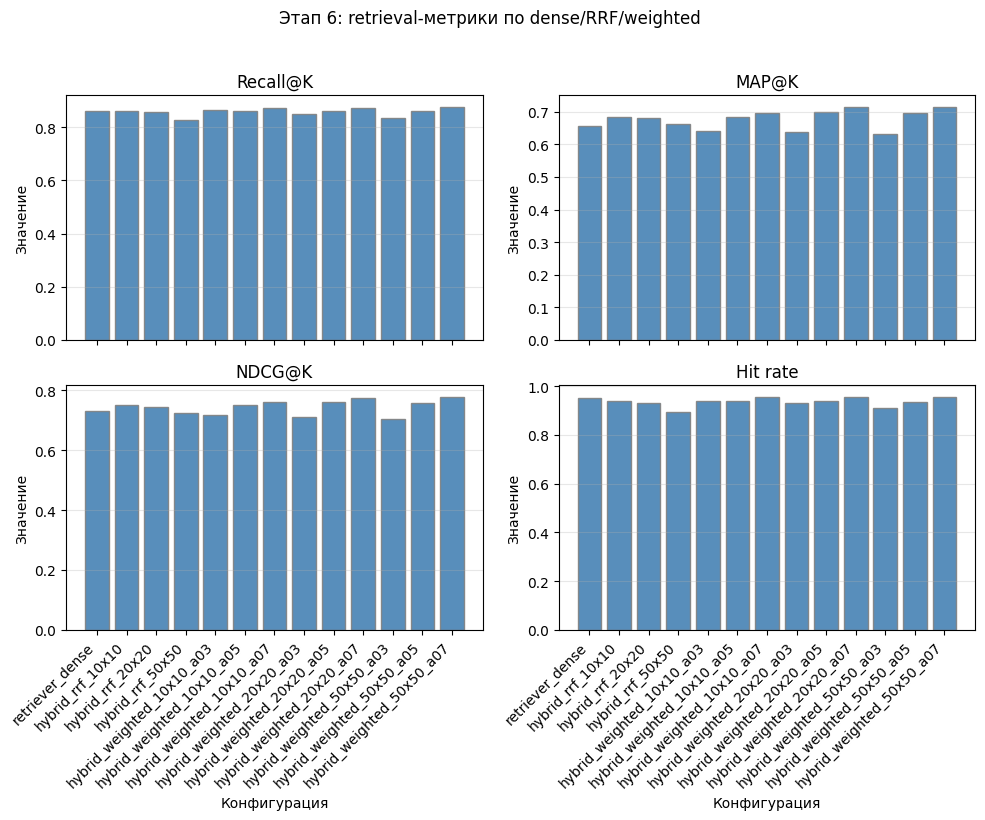

Этап 6 winner (hybrid, по NDCG/MAP): hybrid_weighted_50x50_a07


In [31]:
if len(phase6_retrieval_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    axes = axes.flatten()
    metrics = ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
    metric_titles = {
        "recall_at_k": "Recall@K",
        "map_at_k": "MAP@K",
        "ndcg_at_k": "NDCG@K",
        "hit_rate": "Hit rate",
    }
    x_pos = range(len(phase6_retrieval_df))
    labels = phase6_retrieval_df["experiment_id"].tolist()
    for idx, m in enumerate(metrics):
        ax = axes[idx]
        if m in phase6_retrieval_df.columns:
            ax.bar(x_pos, phase6_retrieval_df[m], color="steelblue", edgecolor="gray", alpha=0.9)
        ax.set_title(metric_titles.get(m, m))
        ax.set_ylabel("Значение")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.grid(True, alpha=0.3, axis="y")
    axes[2].set_xlabel("Конфигурация")
    axes[3].set_xlabel("Конфигурация")
    plt.suptitle("Этап 6: retrieval-метрики по dense/RRF/weighted", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

phase6_hybrid_candidates = phase6_retrieval_df[phase6_retrieval_df["experiment_id"] != "retriever_dense"]
if not phase6_hybrid_candidates.empty and "ndcg_at_k" in phase6_hybrid_candidates.columns:
    phase6_hybrid_winner = phase6_hybrid_candidates.sort_values(["ndcg_at_k", "map_at_k"], ascending=False).iloc[0]
    BEST_HYBRID_ID = str(phase6_hybrid_winner["experiment_id"])
    BEST_HYBRID_OVERRIDES = next(item["overrides"] for item in STAGE6_HYBRID_GRID if item["id"] == BEST_HYBRID_ID)
else:
    BEST_HYBRID_ID = None
    BEST_HYBRID_OVERRIDES = []

print("Этап 6 winner (hybrid, по NDCG/MAP):", BEST_HYBRID_ID)

- **Что сравнивали**: dense baseline (`retriever_dense` / `phase1_dense`), RRF-гибрид (`k ∈ {10, 20, 50}`) и weighted-гибрид (`k ∈ {10, 20, 50}`, `alpha ∈ {0.3, 0.5, 0.7}`) при фиксированных лучших настройках этапов 1-5.
- **На что смотрим**: основные метрики ранжирования - `ndcg_at_k` и `map_at_k`; дополнительно проверяем `recall_at_k`, `hit_rate` и задержку (`mean_query_ms`, `p95_query_ms`), потому что гибридный поиск дороже dense.
- **Формальный winner**: максимум по `ndcg_at_k`/`map_at_k` даёт `hybrid_weighted_50x50_a07`. По сравнению с dense baseline он повышает `NDCG@K` примерно с `0.730` до `0.778`, `MAP@K` с `0.657` до `0.715`, `Recall@K` с `0.863` до `0.877`.
- **Компромисс**: `hybrid_weighted_20x20_a07` почти не уступает `50x50_a07` по качеству (`NDCG@K` около `0.775`, `MAP@K` около `0.714`), но использует меньший candidate pool. Это более компактный вариант для следующих, более дорогих генеративных прогонов.
- **Практический выбор для этапов 7-8**: сохраняем формальный winner в `BEST_HYBRID_ID`, но для продолжения используем `SELECTED_HYBRID_ID = "hybrid_weighted_20x20_a07"` и `SELECTED_HYBRID_OVERRIDES`.

In [32]:
SELECTED_HYBRID_ID = "hybrid_weighted_20x20_a07"
SELECTED_HYBRID_OVERRIDES = next(
    (item["overrides"] for item in STAGE6_HYBRID_GRID if item["id"] == SELECTED_HYBRID_ID),
    [],
)
if not SELECTED_HYBRID_OVERRIDES:
    SELECTED_HYBRID_ID = BEST_HYBRID_ID
    SELECTED_HYBRID_OVERRIDES = list(BEST_HYBRID_OVERRIDES)

print("Этап 6 selected hybrid for stages 7-8:", SELECTED_HYBRID_ID)

Этап 6 selected hybrid for stages 7-8: hybrid_weighted_20x20_a07


## Этап 7 - подбор модели генератора (LLM)

In [33]:
# Сетка этапа 7: перебор моделей генератора при фиксированном режиме ретривера
LLM_MODELS = ["qwen2.5:1.5b", "qwen2.5:7b-instruct", "qwen3:8b"]  # подставить свои модели Ollama
BEST_RETRIEVAL_MODE = "hybrid"  # "hybrid" | "dense"


def stage7_retrieval_overrides() -> list[str]:
    if BEST_RETRIEVAL_MODE == "hybrid":
        return list(SELECTED_HYBRID_OVERRIDES) if SELECTED_HYBRID_OVERRIDES else list(BASE_OVERRIDES)
    return list(BASE_OVERRIDES)


def stage7_overrides(llm_model: str):
    return [
        f"llm.model={llm_model}",
        *without_llm_model_override(list(stage7_retrieval_overrides())),
    ]


stage7_prefix = "gen_hybrid" if BEST_RETRIEVAL_MODE == "hybrid" else "gen_dense"
STAGE7_GRID = []
for model in LLM_MODELS:
    exp_id = f"{stage7_prefix}_" + model.replace(":", ".")
    STAGE7_GRID.append({
        "id": exp_id,
        "overrides": stage7_overrides(model),
        "llm_model": model,
        "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
    })
print(f"Этап 7: {len(STAGE7_GRID)} экспериментов (модели генератора, retrieval={BEST_RETRIEVAL_MODE}, hybrid={SELECTED_HYBRID_ID})")

Этап 7: 3 экспериментов (модели генератора, retrieval=hybrid, hybrid=hybrid_weighted_20x20_a07)


In [34]:
phase7_results = []
for item in STAGE7_GRID:
    exp_id = item["id"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if SKIP_IF_EXISTS and out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase7_results.append(json.load(f))
        continue
    if EVAL_DATASET_HF_REPO:
        cfg = get_cfg(item["overrides"])
        result = run_full_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
            use_llm_judge=True,
            output_path=out_path,
            skip_retriever_eval=True,
        )
        phase7_results.append(result)
    elif out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase7_results.append(json.load(f))

print(f"Этап 7: {len(phase7_results)} результатов")


Этап 7: 3 результатов


In [35]:
pipeline_metrics = [
    "chrfpp",
    "rouge1_recall", "rouge2_recall", "rougeL_f1",
    "semantic_similarity",
    "llm_faithfulness", "llm_answer_relevance", "llm_correctness"
]
phase7_df = pd.DataFrame([
    {
        "experiment_id": STAGE7_GRID[i]["id"],
        "llm_model": STAGE7_GRID[i]["llm_model"],
        **{k: v for k, v in r.get("pipeline", {}).items() if k in pipeline_metrics},
    }
    for i, r in enumerate(phase7_results)
])


In [36]:
phase7_pivot = phase7_df.set_index("experiment_id")
phase7_pivot


,llm_model,chrfpp,rouge1_recall,rouge2_recall,rougeL_f1,semantic_similarity,llm_faithfulness,llm_answer_relevance,llm_correctness
experiment_id,,,,,,,,,
gen_hybrid_qwen2.5.1.5b,qwen2.5:1.5b,0.372220,0.626756,0.415262,0.280709,0.708455,0.722362,0.66625,0.681250
gen_hybrid_qwen2.5.7b-instruct,qwen2.5:7b-instruct,0.371044,0.781329,0.568959,0.273559,0.695769,0.831658,0.74875,0.801250
gen_hybrid_qwen3.8b,qwen3:8b,0.244347,0.495450,0.345549,0.180589,0.645339,0.873162,0.75000,0.815693


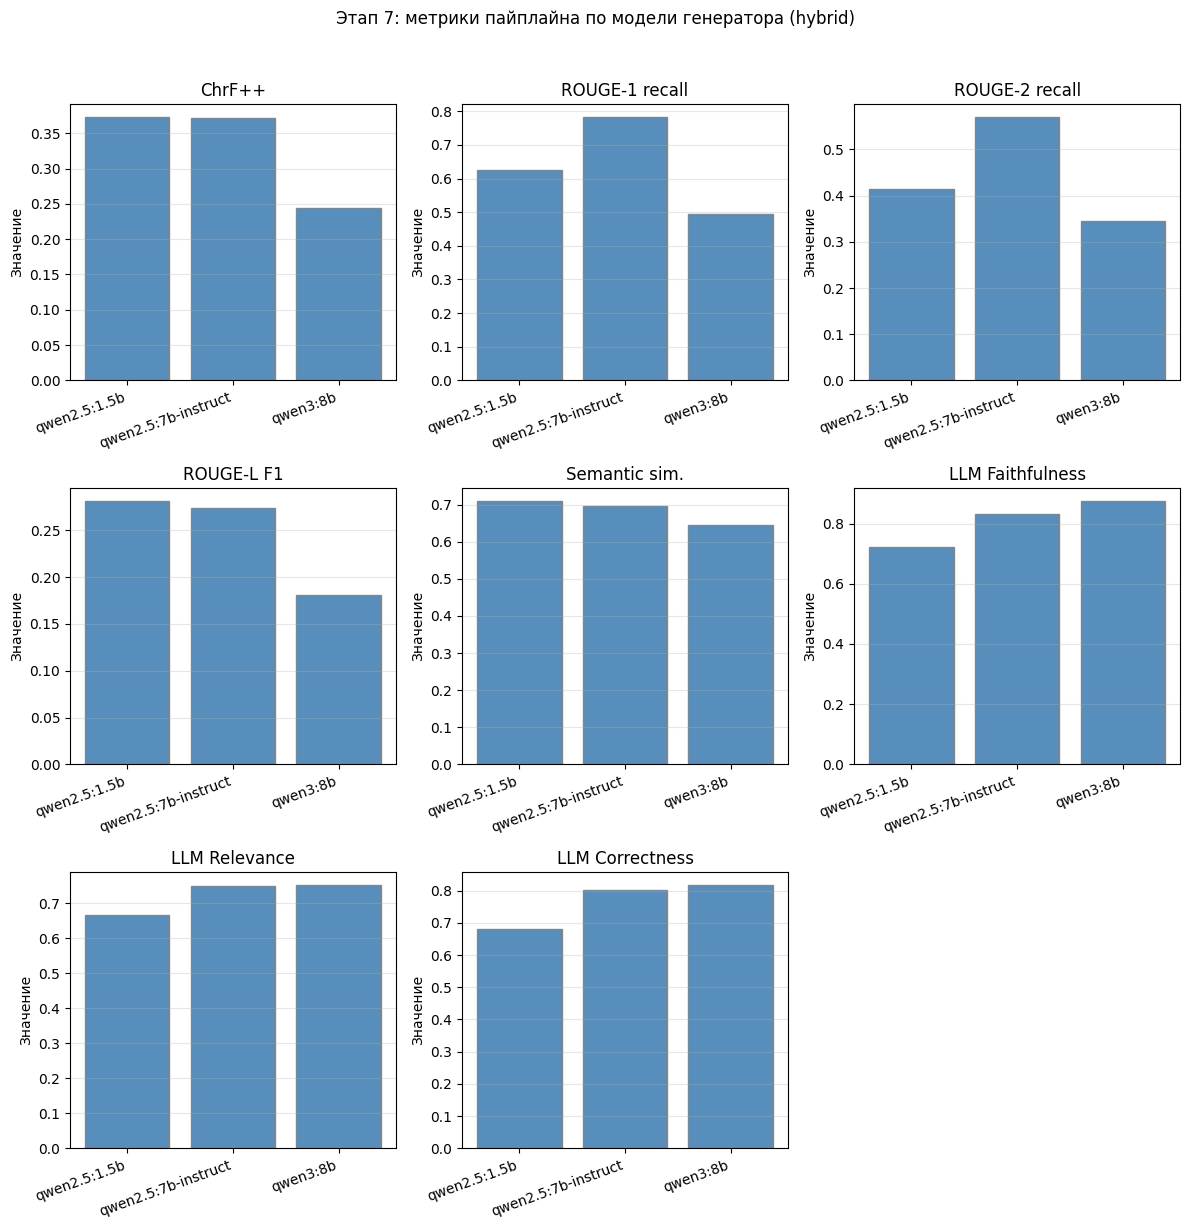

In [37]:
pipeline_metrics = [
    "chrfpp", "rouge1_recall", "rouge2_recall", "rougeL_f1", "semantic_similarity",
    "llm_faithfulness", "llm_answer_relevance", "llm_correctness",
]
metrics_7 = [c for c in pipeline_metrics if c in phase7_df.columns]
metric_titles_7 = {
    "chrfpp": "ChrF++",
    "rouge1_recall": "ROUGE-1 recall",
    "rouge2_recall": "ROUGE-2 recall",
    "rougeL_f1": "ROUGE-L F1",
    "semantic_similarity": "Semantic sim.",
    "llm_faithfulness": "LLM Faithfulness",
    "llm_answer_relevance": "LLM Relevance",
    "llm_correctness": "LLM Correctness",
}
if len(phase7_df) > 0 and metrics_7:
    n_plots = len(metrics_7)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]
    for idx, m in enumerate(metrics_7):
        ax = axes[idx]
        ax.bar(range(len(phase7_df)), phase7_df[m], color="steelblue", edgecolor="gray", alpha=0.9)
        ax.set_title(metric_titles_7.get(m, m))
        ax.set_ylabel("Значение")
        ax.set_xticks(range(len(phase7_df)))
        ax.set_xticklabels(phase7_df["llm_model"].tolist(), rotation=20, ha="right")
        ax.grid(True, alpha=0.3, axis="y")
    for j in range(len(metrics_7), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f"Этап 7: метрики пайплайна по модели генератора ({BEST_RETRIEVAL_MODE})", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


- **Что сравнивали**: несколько моделей из списка `LLM_MODELS` при **фиксированном ретривере**. На этом этапе ретривер уже не меняем - сравниваем именно генерацию.
- **На какие метрики смотрели**:
  - **Текстовые**: `chrfpp`, `rouge1_recall`, `rouge2_recall`, `rougeL_f1` (как прокси «похожести» на эталон).
  - **Семантика**: `semantic_similarity`.
  - **LLM-judge**: `llm_faithfulness`, `llm_answer_relevance`, `llm_correctness` (для RAG это ключевые сигналы качества и опоры на контекст).
- **Наблюдение**: `qwen2.5:7b-instruct` даёт лучший баланс качества и стоимости: она лидирует по `rouge1_recall` и `rouge2_recall`, показывает сильные значения LLM-judge и при этом остаётся легче/быстрее, чем `qwen3:8b`.
- **Компромисс**: `qwen3:8b` немного лучше по `llm_faithfulness` и `llm_correctness`, но заметно проседает по лексическим и семантическим метрикам (`chrfpp`, `rougeL_f1`, `semantic_similarity`) и дороже по времени генерации.
- **Выбор**: **`BEST_LLM_MODEL = "qwen2.5:7b-instruct"`**.
- **Почему**: это наиболее практичный вариант среди проверенных моделей: качество ответа близко к лучшему, покрытие эталонных ответов выше, а ожидаемая скорость лучше, чем у `qwen3:8b`.

## Этап 8 - подбор температуры генерации

In [38]:
# Сетка этапа 8: перебор температуры при фиксированной лучшей модели генератора
BEST_LLM_MODEL = "qwen2.5:7b-instruct"  # из этапа 7: лучшая модель
TEMPERATURE_VALUES = [0.0, 0.1, 0.2, 0.3]
N_RUNS = 3  # прогонов на каждое значение температуры

def stage8_overrides(temperature: float):
    return [
        f"llm.model={BEST_LLM_MODEL}",
        f"llm.temperature={temperature}",
        *without_llm_model_override(list(stage7_retrieval_overrides())),
    ]


stage8_prefix = "temp_hybrid" if BEST_RETRIEVAL_MODE == "hybrid" else "temp_dense"
STAGE8_GRID = []
for t in TEMPERATURE_VALUES:
    for r in range(N_RUNS):
        exp_id = f"{stage8_prefix}_{t}_run{r}"
        STAGE8_GRID.append({
            "id": exp_id,
            "overrides": stage8_overrides(t),
            "temperature": t,
            "run_idx": r,
            "dataset_hf_filename": BEST_DATASET_HF_FILENAME,
        })
print(f"Этап 8: {len(STAGE8_GRID)} экспериментов ({len(TEMPERATURE_VALUES)} temps × {N_RUNS} runs, retrieval={BEST_RETRIEVAL_MODE})")


Этап 8: 12 экспериментов (4 temps × 3 runs, retrieval=hybrid)


In [39]:
phase8_results = []
for item in STAGE8_GRID:
    exp_id = item["id"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if SKIP_IF_EXISTS and out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase8_results.append(json.load(f))
        continue
    if EVAL_DATASET_HF_REPO:
        cfg = get_cfg(item["overrides"])
        result = run_full_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
            use_llm_judge=True,
            skip_retriever_eval=True,
        )
        result["experiment_id"] = exp_id
        result["temperature"] = item["temperature"]
        result["run_idx"] = item["run_idx"]
        pipeline_save = {
            k: v for k, v in result.get("pipeline", {}).items()
            if k not in ("llm_faithfulness_scores", "llm_relevance_scores", "llm_correctness_scores")
        }
        to_save = {
            "experiment_id": exp_id,
            "temperature": item["temperature"],
            "run_idx": item["run_idx"],
            "models": result["models"],
            "retriever": result.get("retriever", {}),
            "pipeline": pipeline_save,
            "n_samples": result["n_samples"],
            "n_evaluated": result.get("n_evaluated"),
            "errors": result.get("errors", 0)
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        phase8_results.append(result)
    elif out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase8_results.append(json.load(f))

print(f"Этап 8: {len(phase8_results)} результатов")

Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:29<00:00,  1.05s/samp]


Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:33<00:00,  1.07s/samp]


Using device: mps


...

Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:33<00:00,  1.07s/samp]


Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:35<00:00,  1.08s/samp]

Этап 8: 12 результатов


In [40]:
# Агрегация по температуре: mean и std по 3 прогонам для каждой метрики
phase8_metrics = [
    "chrfpp", "rougeL_f1", "semantic_similarity",
    "llm_faithfulness", "llm_answer_relevance", "llm_correctness"
]
phase8_raw = []
for r in phase8_results:
    row = {"temperature": r.get("temperature"), "run_idx": r.get("run_idx")}
    for k in phase8_metrics:
        if k in r.get("pipeline", {}):
            row[k] = r["pipeline"][k]
    phase8_raw.append(row)

phase8_runs_df = pd.DataFrame(phase8_raw)
metrics_present = [m for m in phase8_metrics if m in phase8_runs_df.columns]
if metrics_present:
    agg_dict = {m: ["mean", "std"] for m in metrics_present}
    phase8_agg = phase8_runs_df.groupby("temperature").agg(agg_dict).reset_index()
    flat_cols = [
        "temperature"
        if (isinstance(c, tuple) and c[0] == "temperature") or c == "temperature"
        else f"{c[0]}_{c[1]}" for c in phase8_agg.columns
    ]
    phase8_agg.columns = flat_cols
    phase8_df = phase8_agg[["temperature"] + [f"{m}_mean" for m in metrics_present]].copy()
    phase8_df.columns = ["temperature"] + metrics_present
    phase8_std_df = phase8_agg[["temperature"] + [f"{m}_std" for m in metrics_present]].copy()
    phase8_std_df.columns = ["temperature"] + metrics_present
    display(phase8_df)
else:
    phase8_df = pd.DataFrame()
    phase8_std_df = pd.DataFrame()


,temperature,chrfpp,rougeL_f1,semantic_similarity,llm_faithfulness,llm_answer_relevance,llm_correctness
0,0.0,0.373808,0.275142,0.695646,0.835846,0.756250,0.810833
1,0.1,0.373357,0.276199,0.694852,0.834171,0.751667,0.809167
2,0.2,0.373939,0.276800,0.695384,0.832915,0.757917,0.807083
3,0.3,0.370056,0.274211,0.694716,0.832915,0.747917,0.802500


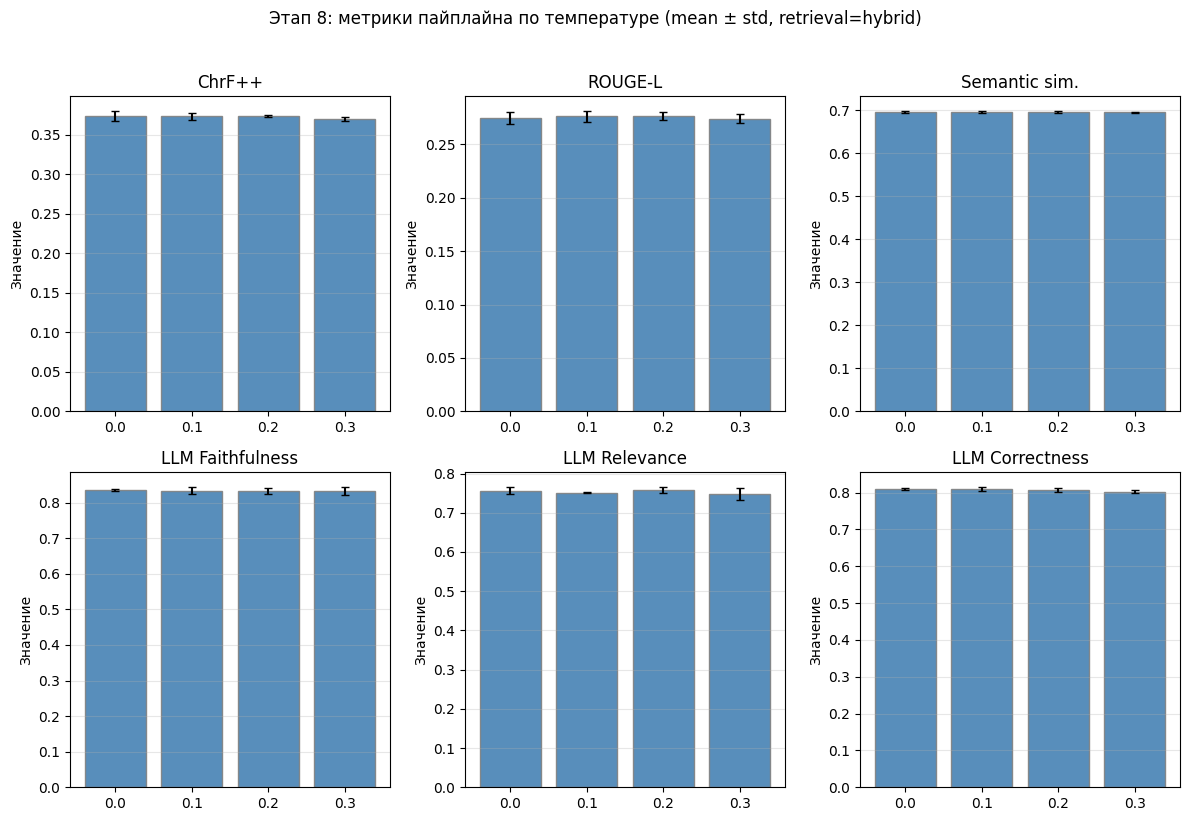

In [41]:
phase8_metric_titles = {
    "chrfpp": "ChrF++",
    "rougeL_f1": "ROUGE-L",
    "semantic_similarity": "Semantic sim.",
    "llm_faithfulness": "LLM Faithfulness",
    "llm_answer_relevance": "LLM Relevance",
    "llm_correctness": "LLM Correctness",
}
if len(phase8_df) > 0 and metrics_present:
    chart_metrics = [m for m in phase8_metrics if m in phase8_df.columns]
    n_plots = len(chart_metrics)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    x = range(len(phase8_df))
    labels = [str(t) for t in phase8_df["temperature"]]
    for idx, m in enumerate(chart_metrics):
        ax = axes[idx]
        ax.bar(x, phase8_df[m], color="steelblue", edgecolor="gray", alpha=0.9, label="mean")
        if m in phase8_std_df.columns and phase8_std_df[m].notna().any():
            ax.errorbar(x, phase8_df[m], yerr=phase8_std_df[m], fmt="none", color="black", capsize=3)
        ax.set_title(phase8_metric_titles.get(m, m))
        ax.set_ylabel("Значение")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.grid(True, alpha=0.3, axis="y")
    for j in range(len(chart_metrics), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f"Этап 8: метрики пайплайна по температуре (mean ± std, retrieval={BEST_RETRIEVAL_MODE})", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- **Что сравнивали**: температуры `0.0 / 0.1 / 0.2 / 0.3` при фиксированных лучших настройках ретривера и выбранной модели генератора. Для каждой температуры сделано **`N_RUNS=3`** прогона, дальше агрегировали **mean/std** по метрикам пайплайна.
- **Наблюдение по устойчивости**: по мере роста температуры обычно растут **разброс (std)** и вариативность ответов - это помогает «креативности», но чаще ухудшает воспроизводимость и строгую привязку к контексту.
- **Что важно в RAG**: приоритет у **`llm_faithfulness`** и **`llm_correctness`** (и их стабильности), потому что эти метрики напрямую отражают «не галлюцинирует ли модель» и «соответствует ли ответ контексту».
- **Выбор**: **`BEST_TEMPERATURE = 0.0`**.
- **Почему**: более высокие значения не дают ощутимого прироста по ключевым метрикам, а нулевая температура является устойчивой и воспроизводимой.


## Полный прогон лучшей конфигурации на тестовом датасете

In [42]:
# Финальная конфигурация по результатам этапов 1–8 (заполнить по результатам или оставить по умолчанию)
BEST_LLM_MODEL = "qwen2.5:7b-instruct"   # из этапа 7: лучшая модель генератора
BEST_TEMPERATURE = 0.0   # из этапа 8: лучшая температура генерации

# Тестовый датасет для финальной оценки (тот же репозиторий, что val; другое имя файла на HF).
FINAL_TEST_DATASET_HF_FILENAME = f"boardgame_rules_qa_test_dataset_ru_chunk{BEST_CHUNK_SIZE}.jsonl"
FINAL_TEST_DATASET_LOCAL_PATH = paths["rag_dir"] / "data" / "test" / f"test_dataset_chunk{BEST_CHUNK_SIZE}.jsonl"

final_overrides = [
    f"llm.temperature={BEST_TEMPERATURE}",
    *without_llm_model_override(list(stage7_retrieval_overrides())),
    f"llm.model={BEST_LLM_MODEL}",
]

final_out_path = RESULTS_DIR / "final_full_eval.json"

final_result = None
if EVAL_DATASET_HF_REPO:
    cfg = get_cfg(final_overrides)
    print("Финальная оценка (тест, HF):", FINAL_TEST_DATASET_HF_FILENAME)
    final_result = run_full_evaluation(
        cfg,
        dataset_hf=EVAL_DATASET_HF_REPO,
        dataset_hf_filename=FINAL_TEST_DATASET_HF_FILENAME,
        limit=LIMIT,
        output_path=final_out_path,
    )
elif FINAL_TEST_DATASET_LOCAL_PATH.is_file():
    cfg = get_cfg(final_overrides + ["data.eval_dataset_hf_repo="])
    print(
        "Финальная оценка (тест, локально):",
        FINAL_TEST_DATASET_LOCAL_PATH.relative_to(paths["rag_dir"]),
    )
    final_result = run_full_evaluation(
        cfg,
        dataset_path=FINAL_TEST_DATASET_LOCAL_PATH,
        limit=LIMIT,
        output_path=final_out_path,
    )
else:
    print(
        "Skip final run: задайте data.eval_dataset_hf_repo или положите тестовый JSONL в",
        FINAL_TEST_DATASET_LOCAL_PATH,
    )

if final_result is not None:
    print("Режим retrieval:", BEST_RETRIEVAL_MODE)
    print("Модели:", final_result.get("models", {}))
    print("Оценено сэмплов:", final_result.get("n_evaluated", 0), "/", final_result.get("n_samples", 0))
    pipe = final_result.get("pipeline", {})
    if pipe.get("llm_n_scored_faithfulness") is not None:
        n = int(pipe["llm_n_scored_faithfulness"])
        na_f = int(pipe.get("llm_n_na_faithfulness", 0))
        na_r = int(pipe.get("llm_n_na_relevance", 0))
        na_c = int(pipe.get("llm_n_na_correctness", 0))
        print(
            "LLM-judge: scored on", n,
            "samples" + (f", N/A (faith/rel/corr): {na_f}/{na_r}/{na_c}" if (na_f or na_r or na_c) else "")
        )

    print("Retriever:", final_result["retriever"])
    print(
        "Pipeline:",
        {
            k: v for k, v in final_result["pipeline"].items()
            if k not in ("llm_faithfulness_scores", "llm_relevance_scores", "llm_correctness_scores")
        }
    )
elif final_out_path.exists():
    with open(final_out_path, encoding="utf-8") as f:
        final_result = json.load(f)

    print("Загружен сохранённый результат из", final_out_path.relative_to(BASE_DIR))
    print("Retriever:", final_result.get("retriever"))
    print(
        "Pipeline (summary):",
        {
            k: v for k, v in (final_result.get("pipeline") or {}).items()
            if k not in ("llm_faithfulness_scores", "llm_relevance_scores", "llm_correctness_scores")
        }
    )
else:
    final_result = {}
    print(
        "Нет сохранённого результата по",
        final_out_path,
        "- задайте HF-репо или локальный тестовый JSONL (см. ячейку выше).",
    )

Финальная оценка (тест, HF): boardgame_rules_qa_test_dataset_ru_chunk128.jsonl
Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:22<00:00,  1.01s/samp]

Режим retrieval: hybrid
Модели: {'generation': 'qwen2.5:7b-instruct', 'embedding': 'intfloat/multilingual-e5-base', 'semantic_eval': 'ai-forever/ru-en-RoSBERTa', 'llm_judge': 'qwen2.5:7b-instruct'}
Оценено сэмплов: 200 / 200
LLM-judge: scored on 200 samples
Retriever: {'recall_at_k': 0.8858333333333336, 'precision_at_k': 0.11599999999999994, 'map_at_k': 0.7235287698412701, 'ndcg_at_k': 0.7842339954733625, 'hit_rate': 0.955}
Pipeline: {'chrfpp': 0.3476277145934844, 'rouge1_recall': 0.7819765805874552, 'rouge2_recall': 0.5396035524932582, 'rougeL_f1': 0.255212772273413, 'semantic_similarity': 0.6721219967499171, 'llm_faithfulness': 0.8125, 'llm_answer_relevance': 0.72125, 'llm_correctness': 0.79875, 'llm_judge_errors': 0.0, 'llm_n_scored_faithfulness': 200.0, 'llm_n_scored_relevance': 200.0, 'llm_n_scored_correctness': 200.0, 'llm_n_na_faithfulness': 0.0, 'llm_n_na_relevance': 0.0, 'llm_n_na_correctness': 0.0}


In [43]:
PIPELINE_SERVICE_KEYS = {
    "n_evaluated", "errors", "llm_judge_errors",
    "llm_n_scored_faithfulness", "llm_n_scored_relevance", "llm_n_scored_correctness",
    "llm_n_na_faithfulness", "llm_n_na_relevance", "llm_n_na_correctness",
    "llm_faithfulness_scores", "llm_relevance_scores", "llm_correctness_scores",
}

metrics_flat = []
for name, val in (final_result.get("retriever") or {}).items():
    metrics_flat.append({"блок": "retriever", "метрика": name, "значение": val})
for name, val in (final_result.get("pipeline") or {}).items():
    if name not in PIPELINE_SERVICE_KEYS:
        metrics_flat.append({"блок": "pipeline", "метрика": name, "значение": val})

final_metrics_df = pd.DataFrame(metrics_flat)

In [44]:
print("Ретривер:")
display(pd.DataFrame(list((final_result.get("retriever") or {}).items()), columns=["метрика", "значение"]))
print("Пайплайн:")
pipe_items = [(k, v) for k, v in (final_result.get("pipeline") or {}).items() if k not in PIPELINE_SERVICE_KEYS]
display(pd.DataFrame(pipe_items, columns=["метрика", "значение"]))

Ретривер:


,метрика,значение
0,recall_at_k,0.885833
1,precision_at_k,0.116000
2,map_at_k,0.723529
3,ndcg_at_k,0.784234
4,hit_rate,0.955000


Пайплайн:


,метрика,значение
0,chrfpp,0.347628
1,rouge1_recall,0.781977
2,rouge2_recall,0.539604
3,rougeL_f1,0.255213
4,semantic_similarity,0.672122
5,llm_faithfulness,0.812500
6,llm_answer_relevance,0.721250
7,llm_correctness,0.798750


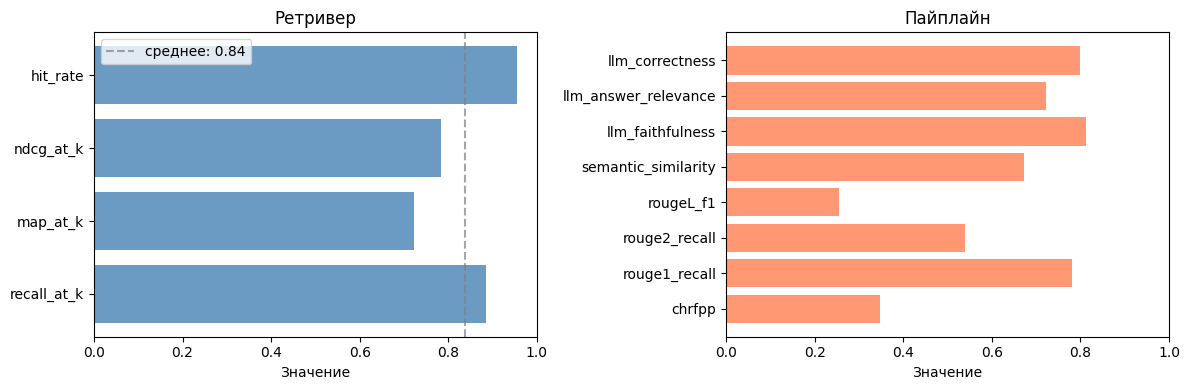

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ret = final_metrics_df[final_metrics_df["блок"] == "retriever"]
ret_plot = ret[ret["метрика"] != "precision_at_k"]
ax = axes[0]
bars = ax.barh(ret_plot["метрика"], ret_plot["значение"], color="steelblue", alpha=0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("Значение")
ax.set_title("Ретривер")
if len(ret_plot):
    ax.axvline(
        x=ret_plot["значение"].mean(),
        color="gray",
        linestyle="--",
        alpha=0.7,
        label=f"среднее: {ret_plot['значение'].mean():.2f}"
    )
    ax.legend()

pipe = final_metrics_df[final_metrics_df["блок"] == "pipeline"]
ax = axes[1]
bars = ax.barh(pipe["метрика"], pipe["значение"], color="coral", alpha=0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("Значение")
ax.set_title("Пайплайн")
plt.tight_layout()
plt.show()

### Распределение оценок LLM-судьи по сэмплам

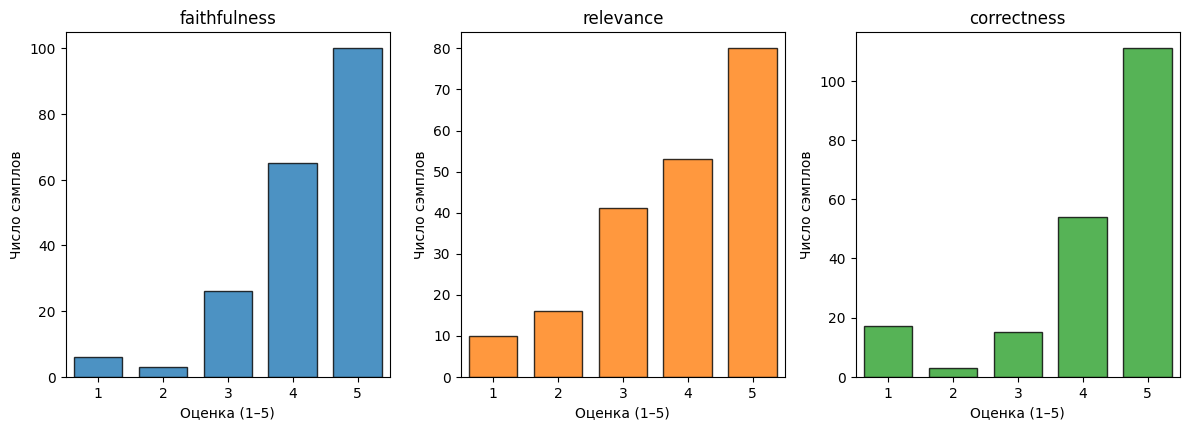

In [46]:
pipe = final_result.get("pipeline", {})
f_scores = pipe.get("llm_faithfulness_scores") or []
r_scores = pipe.get("llm_relevance_scores") or []
c_scores = pipe.get("llm_correctness_scores") or []

f_vals = np.array([x for x in f_scores if x is not None], dtype=float) if f_scores else np.array([])
r_vals = np.array([x for x in r_scores if x is not None], dtype=float) if r_scores else np.array([])
c_vals = np.array([x for x in c_scores if x is not None], dtype=float) if c_scores else np.array([])

fig = plt.figure(figsize=(12, 8))
for idx, (vals, title) in enumerate([
    (f_vals, "faithfulness"),
    (r_vals, "relevance"),
    (c_vals, "correctness"),
]):
    ax = fig.add_subplot(2, 3, idx + 1)
    if len(vals):
        ax.hist(
            vals,
            bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
            range=(0.5, 5.5),
            color=f"C{idx}",
            edgecolor="black",
            alpha=0.8,
            rwidth=0.75
        )
    ax.set_xlabel("Оценка (1–5)")
    ax.set_ylabel("Число сэмплов")
    ax.set_title(title)
    ax.set_xlim(0.5, 5.5)

plt.tight_layout()
plt.show()

## Сравнение с бейзлайном

In [47]:
BASELINE_RESULTS_PATH = RESULTS_DIR / "baseline_full_eval.json"

if BASELINE_RESULTS_PATH.exists():
    with open(BASELINE_RESULTS_PATH, encoding="utf-8") as f:
        baseline_result = json.load(f)
    print("Загружен бейзлайн из", BASELINE_RESULTS_PATH.relative_to(BASE_DIR))
else:
    print("Бейзлайн не найден, запускаю оценку...")
    if not EVAL_DATASET_HF_REPO:
        raise ValueError("EVAL_DATASET_HF_REPO не задан - запустите 03_baseline_evaluation или задайте data.eval_dataset_hf_repo")
    cfg_baseline = get_cfg()
    baseline_result = run_full_evaluation(
        cfg_baseline,
        dataset_hf=EVAL_DATASET_HF_REPO,
        dataset_hf_filename="boardgame_rules_qa_dataset_ru_chunk512.jsonl",
        output_path=BASELINE_RESULTS_PATH,
    )

Загружен бейзлайн из research/rag_experiments/results/baseline_full_eval.json


In [48]:
COMPARISON_KEYS = [
    "recall_at_k", "precision_at_k", "map_at_k", "ndcg_at_k", "hit_rate",
    "chrfpp", "rouge1_recall", "rouge2_recall", "rougeL_f1", "semantic_similarity",
    "llm_faithfulness", "llm_answer_relevance", "llm_correctness",
]

def _get_val(d: dict, key: str):
    ret = (d.get("retriever") or {}).get(key)
    if ret is not None:
        return ret
    return (d.get("pipeline") or {}).get(key)

rows = []
for key in COMPARISON_KEYS:
    b_val = _get_val(baseline_result, key)
    f_val = _get_val(final_result, key)
    if b_val is not None or f_val is not None:
        b_val = b_val if b_val is not None else float("nan")
        f_val = f_val if f_val is not None else float("nan")
        delta = f_val - b_val if isinstance(b_val, (int, float)) and isinstance(f_val, (int, float)) else None
        rows.append({"метрика": key, "baseline": b_val, "best": f_val, "Δ": delta})

comparison_df = pd.DataFrame(rows)
display(comparison_df)

,метрика,baseline,best,Δ
0,recall_at_k,0.693333,0.885833,0.192500
1,precision_at_k,0.182000,0.116000,-0.066000
2,map_at_k,0.533222,0.723529,0.190307
3,ndcg_at_k,0.585582,0.784234,0.198652
4,hit_rate,0.750000,0.955000,0.205000
5,chrfpp,0.344467,0.347628,0.003161
6,rouge1_recall,0.612631,0.781977,0.169346
7,rouge2_recall,0.397663,0.539604,0.141940
8,rougeL_f1,0.262656,0.255213,-0.007443
9,semantic_similarity,0.699523,0.672122,-0.027401


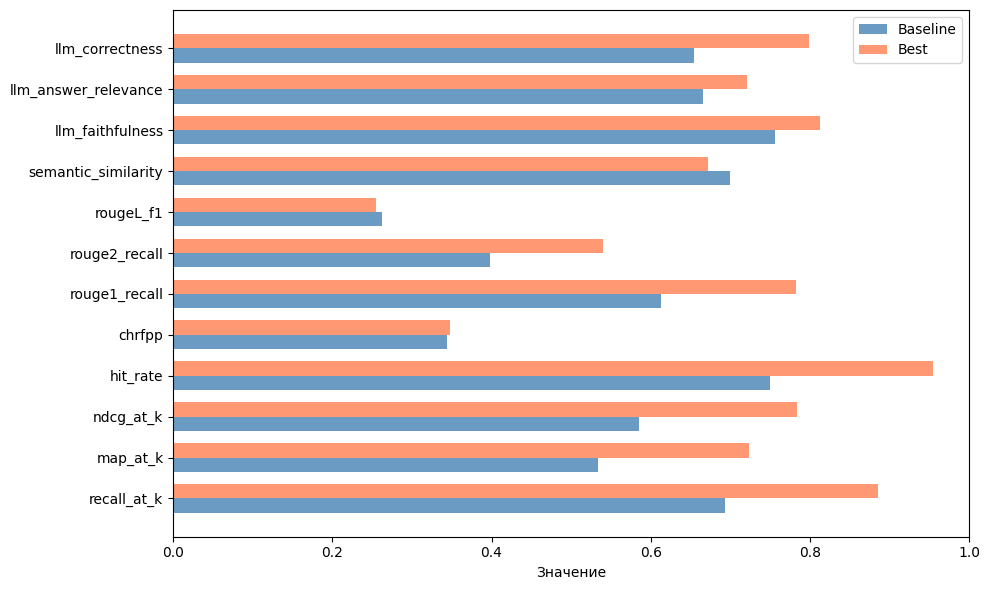

In [51]:
if len(comparison_df) > 0:
    comparison_plot = comparison_df[comparison_df["метрика"] != "precision_at_k"]
    fig, ax = plt.subplots(figsize=(10, max(6, len(comparison_plot) * 0.4)))
    x = np.arange(len(comparison_plot))
    width = 0.35
    ax.barh(x - width/2, comparison_plot["baseline"], width, label="Baseline", color="steelblue", alpha=0.8)
    ax.barh(x + width/2, comparison_plot["best"], width, label="Best", color="coral", alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(comparison_plot["метрика"])
    ax.set_xlabel("Значение")
    ax.legend()
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

## Итоговые выводы

- **Метрики ретривера (baseline vs best)**:
  - **Recall@k**: 0.693 → **0.886** (+0.193)
  - **MAP@k**: 0.533 → **0.724** (+0.191)
  - **nDCG@k**: 0.586 → **0.784** (+0.198)
  - **Hit rate**: 0.750 → **0.955** (+0.205)
  - **Интерпретация**: финальная конфигурация заметно лучше находит релевантные фрагменты и лучше ранжирует их в top-K. `precision_at_k` не используем как ключевой критерий, потому что при большем/другом составе выдачи она хуже отражает полезность retrieval для RAG, чем recall/MAP/nDCG/hit rate.

- **Метрики генерации (baseline vs best)**:
  - **ChrF++**: 0.344 → **0.348** (+0.004)
  - **ROUGE-1 recall**: 0.613 → **0.782** (+0.169)
  - **ROUGE-2 recall**: 0.398 → **0.540** (+0.142)
  - **ROUGE-L F1**: 0.263 → **0.255** (-0.008)
  - **Semantic similarity**: 0.700 → **0.672** (-0.028)
  - **LLM faithfulness**: 0.756 → **0.813** (+0.057)
  - **LLM answer relevance**: 0.666 → **0.721** (+0.055)
  - **LLM correctness**: 0.655 → **0.799** (+0.144)

- **Интерпретация генерации**: best-конфигурация сильнее покрывает эталонные ответы по ROUGE-1/ROUGE-2 и заметно лучше по LLM-judge метрикам. При этом небольшое снижение `rougeL_f1` и `semantic_similarity` показывает, что улучшение не является равномерным по всем автоматическим метрикам: ответы могут отличаться по структуре и формулировкам от эталона. Поэтому финальное решение опираем на совокупность retrieval-метрик, ROUGE recall и LLM-judge, а не на одну отдельную метрику.

- **Практический вывод**: финальная конфигурация даёт существенный прирост качества RAG по сравнению с baseline: retrieval стал полнее и лучше ранжирует релевантные фрагменты, а ответы - более релевантными, корректными и лучше grounded в контексте. Поэтому фиксируем её как итоговый вариант для сравнения с бейзлайном.